In [10]:
!pip install -q "transformers>=4.37.0" accelerate sentencepiece protobuf flash-attn --no-build-isolation

In [11]:
import transformers
print(f"Transformers version: {transformers.__version__}")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Transformers version: 5.2.0
PyTorch: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA H100 80GB HBM3


In [12]:
import os, re, time, json
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

# Config
MODEL_NAME       = "Qwen/Qwen2.5-7B-Instruct"
MAX_SAMPLES      = 500
MAX_NEW_TOKENS   = 1024
EVAL_BATCH_SIZE  = 64
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")


Device: cuda


Logged in to Hugging Face.


In [14]:
import glob

matches = glob.glob('/kaggle/input/**/math_500_test.csv', recursive=True)
DATA_PATH = matches[0] if matches else '/kaggle/input/math-500/math_500_test.csv'
print(f"Loading from: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)[['Question', 'Answer']].head(MAX_SAMPLES).reset_index(drop=True)
print(f"Loaded {len(df)} questions")

Loading from: /kaggle/input/datasets/vybhavchaturvedi/math-500/math_500_test.csv
Loaded 500 questions


In [15]:
print("Tokenizer Load")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, padding_side='left')
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()
print(f"Model on: {next(model.parameters()).device}")


Loading tokenizer...
Loading model in bfloat16 (H100 has 80GB, no quantization needed)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✅ Model on: cuda:0


In [16]:
def extract_boxed(text):
    text = str(text)
    # Try \boxed{...} with nested brace matching
    idx = text.find('\\boxed{')
    if idx != -1:
        depth, start, end = 1, idx + 7, idx + 7
        while end < len(text) and depth > 0:
            if text[end] == '{': depth += 1
            elif text[end] == '}': depth -= 1
            end += 1
        if depth == 0:
            return text[start:end-1]
    match = re.search(r'final answer is[:\s]*([^\n.]+)', text, re.IGNORECASE)
    return match.group(1).strip() if match else text.strip()

def normalize(ans):
    ans = str(ans).strip()
    ans = re.sub(r'\\text\{([^}]*)\}', r'\1', ans)
    ans = re.sub(r'\\frac\{([^}]*)\}\{([^}]*)\}', r'(\1)/(\2)', ans)
    return re.sub(r'[^\w.+\-/]', '', ans.lower())

def is_correct(pred, gt):
    p, g = normalize(extract_boxed(pred)), normalize(extract_boxed(gt))
    if p == g: return True
    try:
        return abs(float(p.replace('^','**')) - float(g.replace('^','**'))) < 1e-6
    except:
        return False

In [17]:
# Prompts taken form the orig Research Paper
PROMPTS = {
    "Original":     "Solve the following math problem step by step. Put your final answer within \\boxed{{}}.\n\nProblem: {question}\n\nSolution:",
    "BeConcise":    "Be concise. Solve the following math problem step by step. Put your final answer within \\boxed{{}}.\n\nProblem: {question}\n\nSolution:",
    "OnlyNumbers":  "Only use numbers or equations. Solve the following math problem step by step. Put your final answer within \\boxed{{}}.\n\nProblem: {question}\n\nSolution:",
    "AbbreWords":   "Abbreviate words as much as possible. Solve the following math problem step by step. Put your final answer within \\boxed{{}}.\n\nProblem: {question}\n\nSolution:",
}

def make_prompt(question, method):
    prompt = PROMPTS[method].format(question=question)
    messages = [{"role": "user", "content": prompt}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

In [18]:
def evaluate_batched(df, method="Original", max_new_tokens=MAX_NEW_TOKENS, original_avg_tokens=None):
    all_responses    = []
    all_token_counts = [] 
    start_time       = time.time()

    prompts = [make_prompt(row['Question'], method) for _, row in df.iterrows()]

    for batch_start in tqdm(range(0, len(prompts), EVAL_BATCH_SIZE),
                             desc=f"{method} (batch={EVAL_BATCH_SIZE})"):
        batch_prompts = prompts[batch_start:batch_start + EVAL_BATCH_SIZE]

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=2048
        ).to(DEVICE)

        input_len = inputs['input_ids'].shape[1]

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        generated    = outputs[:, input_len:]
        token_counts = (generated != tokenizer.pad_token_id).sum(dim=1).tolist()
        all_token_counts.extend(token_counts)

        responses = tokenizer.batch_decode(generated, skip_special_tokens=True)
        all_responses.extend(responses)

        del outputs, inputs, generated
        torch.cuda.empty_cache()

    elapsed    = time.time() - start_time
    correct    = sum(is_correct(r, g) for r, g in zip(all_responses, df['Answer']))
    avg_tokens = sum(all_token_counts) / len(df)

    return {
        'Method':     method,
        'Accuracy':   round(100 * correct / len(df), 2),
        'Avg Tokens': round(avg_tokens, 2),
        'Latency(s)': round(elapsed / len(df), 3),
        'Act Ratio':  round(avg_tokens / original_avg_tokens if original_avg_tokens else 1.0, 3),
        'Correct':    correct,
        'Total':      len(df),
    }, all_responses, all_token_counts 


In [19]:
all_results          = []
all_responses_dict   = {}
all_token_counts_dict = {}
checkpoint_path      = "/kaggle/working/tokenskip_checkpoint.json"

if os.path.exists(checkpoint_path):
    with open(checkpoint_path) as f:
        checkpoint = json.load(f)
    all_results       = checkpoint.get('results', [])
    completed_methods = {r['Method'] for r in all_results}
    print(f"Resuming: {completed_methods} already done")
else:
    completed_methods = set()

eval_start = time.time()

for method in ["Original", "BeConcise", "OnlyNumbers", "AbbreWords"]:
    if method in completed_methods:
        print(f"Skipping {method} (already done)")
        continue

    print(f"\n{'='*60}\nEvaluating: {method}\n{'='*60}")
    orig_tokens = next((r['Avg Tokens'] for r in all_results if r['Method'] == 'Original'), None)

    result, responses, token_counts = evaluate_batched(df, method=method, original_avg_tokens=orig_tokens)
    all_results.append(result)
    all_responses_dict[method]    = responses
    all_token_counts_dict[method] = token_counts
    print(f"{method}: {result['Accuracy']:.1f}% acc | {result['Avg Tokens']:.1f} tokens | {result['Latency(s)']:.2f}s/sample")

    with open(checkpoint_path, 'w') as f:
        json.dump({'results': all_results}, f)

orig_tokens = next(r['Avg Tokens'] for r in all_results if r['Method'] == 'Original')

for ratio in [0.9, 0.8, 0.7, 0.6, 0.5]:
    method_key = f"Truncation_{ratio}"
    if method_key in completed_methods:
        print(f"Skipping {method_key} (already done)")
        continue

    print(f"\n{'='*60}\nEvaluating: Truncation ratio={ratio}\n{'='*60}")
    max_tok = int(MAX_NEW_TOKENS * ratio)

    result, responses, token_counts = evaluate_batched(df, method="Original", max_new_tokens=max_tok, original_avg_tokens=orig_tokens)
    result['Method'] = method_key
    result['Ratio']  = ratio
    all_results.append(result)
    all_responses_dict[method_key]    = responses
    all_token_counts_dict[method_key] = token_counts   # store counts
    print(f"Truncation {ratio}: {result['Accuracy']:.1f}% acc | {result['Avg Tokens']:.1f} tokens")

    with open(checkpoint_path, 'w') as f:
        json.dump({'results': all_results}, f)

total_time = time.time() - eval_start
print(f"\nAll evaluations complete in {total_time/3600:.2f} hours")



Evaluating: Original


Original (batch=64):   0%|          | 0/8 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Original: 69.0% acc | 559.7 tokens | 3.20s/sample

Evaluating: BeConcise


BeConcise (batch=64):   0%|          | 0/8 [00:00<?, ?it/s]

...

Truncation 0.7: 59.6% acc | 507.0 tokens

Evaluating: Truncation ratio=0.6


Original (batch=64):   0%|          | 0/8 [00:00<?, ?it/s]

Truncation 0.6: 54.4% acc | 472.4 tokens

Evaluating: Truncation ratio=0.5


Original (batch=64):   0%|          | 0/8 [00:00<?, ?it/s]

Truncation 0.5: 46.6% acc | 431.7 tokens

All evaluations complete in 1.15 hours


In [26]:
final_df = pd.DataFrame(all_results)

orig_tokens = final_df[final_df['Method'] == 'Original']['Avg Tokens'].values[0]
orig_acc    = final_df[final_df['Method'] == 'Original']['Accuracy'].values[0]

final_df['Token Savings (%)'] = ((1 - final_df['Avg Tokens'] / orig_tokens) * 100).round(2)
final_df['Accuracy Drop']     = (orig_acc - final_df['Accuracy']).round(2)
final_df['Efficiency Score']  = (final_df['Accuracy'] / final_df['Avg Tokens'] * 100).round(3)

final_df.to_csv("/kaggle/working/tokenskip_results.csv", index=False)

print("=" * 70)
print("TOKENSKIP FULL RESULTS — MATH-500 (500 samples)")
print("=" * 70)
print(final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                 'Accuracy Drop', 'Act Ratio', 'Latency(s)']].to_string(index=False))
print("=" * 70)

ranked = final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                    'Efficiency Score']].sort_values('Efficiency Score', ascending=False)
print("\nEFFICIENCY RANKING")
print(ranked.to_string(index=False))

best_eff     = final_df[final_df['Method'] != 'Original'].sort_values('Efficiency Score', ascending=False).iloc[0]
most_savings = final_df.sort_values('Token Savings (%)', ascending=False).iloc[0]
best_acc     = final_df.sort_values('Accuracy', ascending=False).iloc[0]

print("\nKEY FINDINGS")
print("=" * 70)
print(f"Best Efficiency Method : {best_eff['Method']} (score={best_eff['Efficiency Score']:.3f})")
print(f"Most Token Savings     : {most_savings['Method']} ({most_savings['Token Savings (%)']:.1f}% saved)")
print(f"Best Accuracy          : {best_acc['Method']} ({best_acc['Accuracy']:.1f}%)")
print(f"Baseline (Original)    : {orig_acc:.1f}% acc, {orig_tokens:.0f} avg tokens")


TOKENSKIP FULL RESULTS — MATH-500 (500 samples)
        Method  Accuracy  Avg Tokens  Token Savings (%)  Accuracy Drop  Act Ratio  Latency(s)
      Original      69.0      559.66               0.00            0.0      1.000       3.199
     BeConcise      68.8      463.51              17.18            0.2      0.828       0.833
   OnlyNumbers      53.4      342.73              38.76           15.6      0.612       0.821
    AbbreWords      69.8      489.26              12.58           -0.8      0.874       0.834
Truncation_0.9      67.6      545.97               2.45            1.4      0.976       0.708
Truncation_0.8      63.0      528.73               5.53            6.0      0.945       0.604
Truncation_0.7      59.6      506.99               9.41            9.4      0.906       0.511
Truncation_0.6      54.4      472.42              15.59           14.6      0.844       0.422
Truncation_0.5      46.6      431.72              22.86           22.4      0.771       0.337

EFFICIENCY 

In [27]:
tradeoff = final_df[['Method', 'Accuracy', 'Token Savings (%)', 'Accuracy Drop']].copy()
tradeoff['Acc Drop per 10% Savings'] = (
    tradeoff['Accuracy Drop'] / (tradeoff['Token Savings (%)'] / 10)
).round(3)
tradeoff.loc[tradeoff['Token Savings (%)'] <= 0, 'Acc Drop per 10% Savings'] = 0.0

print("ACCURACY-EFFICIENCY TRADEOFF")
print("(How much accuracy is lost per 10% token savings)")
print("=" * 70)
print(tradeoff.to_string(index=False))

ACCURACY-EFFICIENCY TRADEOFF
(How much accuracy is lost per 10% token savings)
        Method  Accuracy  Token Savings (%)  Accuracy Drop  Acc Drop per 10% Savings
      Original      69.0               0.00            0.0                     0.000
     BeConcise      68.8              17.18            0.2                     0.116
   OnlyNumbers      53.4              38.76           15.6                     4.025
    AbbreWords      69.8              12.58           -0.8                    -0.636
Truncation_0.9      67.6               2.45            1.4                     5.714
Truncation_0.8      63.0               5.53            6.0                    10.850
Truncation_0.7      59.6               9.41            9.4                     9.989
Truncation_0.6      54.4              15.59           14.6                     9.365
Truncation_0.5      46.6              22.86           22.4                     9.799


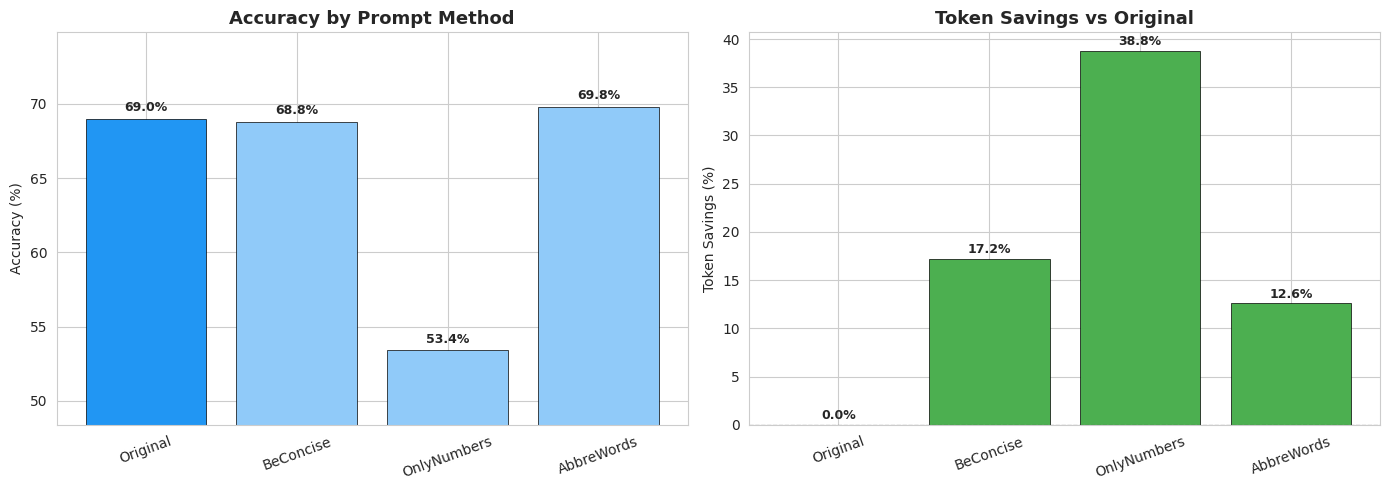

In [28]:
prompt_df = final_df[~final_df['Method'].str.contains("Truncation")].copy()

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3' if m == 'Original' else '#90CAF9' for m in prompt_df['Method']]
bars = axes[0].bar(prompt_df['Method'], prompt_df['Accuracy'],
                    color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title("Accuracy by Prompt Method", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(prompt_df['Accuracy'].min() - 5, prompt_df['Accuracy'].max() + 5)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, prompt_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

colors2 = ['#4CAF50' if s > 0 else '#F44336' for s in prompt_df['Token Savings (%)']]
bars2 = axes[1].bar(prompt_df['Method'], prompt_df['Token Savings (%)'],
                     color=colors2, edgecolor='black', linewidth=0.5)
axes[1].set_title("Token Savings vs Original", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Token Savings (%)")
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars2, prompt_df['Token Savings (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("/kaggle/working/prompt_methods.png", dpi=300, bbox_inches='tight')
plt.show()


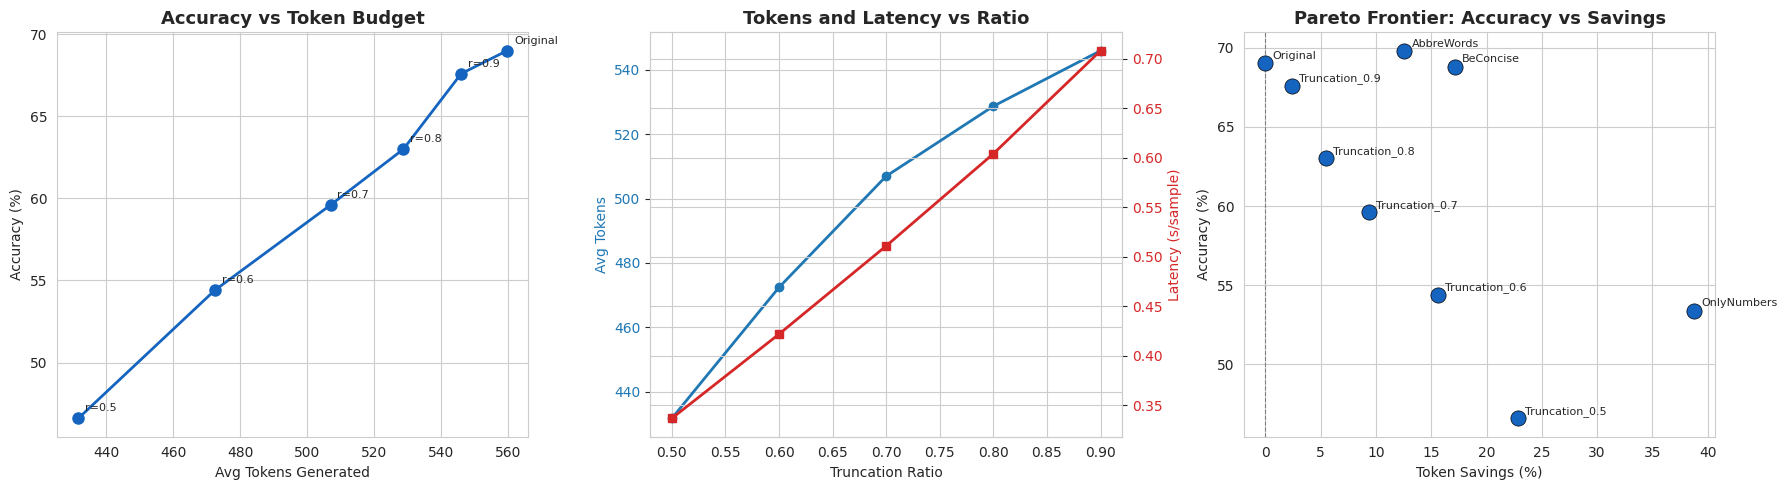

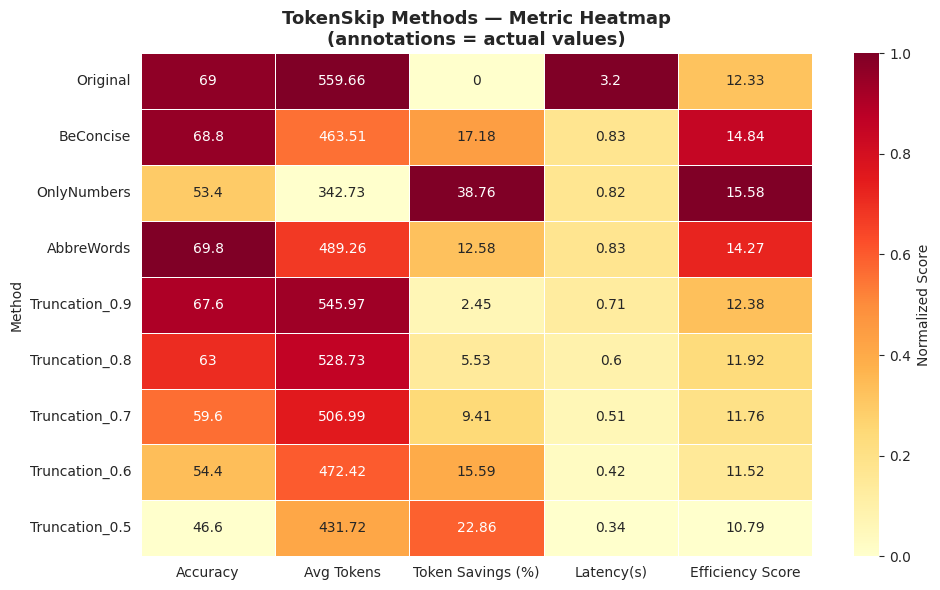

In [29]:
trunc_df = final_df[final_df['Method'].str.contains("Truncation")].copy().sort_values('Ratio')
trunc_with_orig = pd.concat([
    final_df[final_df['Method'] == 'Original'],
    trunc_df
]).sort_values('Avg Tokens')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(trunc_with_orig['Avg Tokens'], trunc_with_orig['Accuracy'],
             'o-', color='#1565C0', linewidth=2, markersize=8)
for _, row in trunc_with_orig.iterrows():
    label = f"r={row['Ratio']}" if pd.notna(row.get('Ratio')) else 'Original'
    axes[0].annotate(label, (row['Avg Tokens'], row['Accuracy']),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[0].set_xlabel("Avg Tokens Generated")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy vs Token Budget", fontsize=13, fontweight='bold')

ax1 = axes[1]
ax2 = ax1.twinx()
ax1.plot(trunc_df['Ratio'], trunc_df['Avg Tokens'], 'o-', color='tab:blue', linewidth=2)
ax2.plot(trunc_df['Ratio'], trunc_df['Latency(s)'], 's-', color='tab:red', linewidth=2)
ax1.set_xlabel("Truncation Ratio")
ax1.set_ylabel("Avg Tokens", color='tab:blue')
ax2.set_ylabel("Latency (s/sample)", color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
axes[1].set_title("Tokens and Latency vs Ratio", fontsize=13, fontweight='bold')

axes[2].scatter(final_df['Token Savings (%)'], final_df['Accuracy'],
                s=120, c='#1565C0', zorder=5, edgecolors='black', linewidth=0.5)
for _, row in final_df.iterrows():
    axes[2].annotate(row['Method'], (row['Token Savings (%)'], row['Accuracy']),
                     textcoords="offset points", xytext=(5, 3), fontsize=8)
axes[2].set_xlabel("Token Savings (%)")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Pareto Frontier: Accuracy vs Savings", fontsize=13, fontweight='bold')
axes[2].axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig("/kaggle/working/truncation_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Heatmap
pivot = final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                   'Latency(s)', 'Efficiency Score']].set_index('Method')
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_norm, annot=pivot.round(2), fmt='g', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Score'})
ax.set_title("TokenSkip Methods — Metric Heatmap\n(annotations = actual values)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/method_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


In [51]:
print(pd.read_csv(DATA_PATH).columns.tolist())

from datasets import load_dataset

ds     = load_dataset("HuggingFaceH4/MATH-500", split="test")
df_meta = ds.to_pandas()
df_meta = df_meta.rename(columns={'problem': 'Question'})[['Question', 'level', 'subject']]

df = df.drop(columns=[c for c in ['level', 'subject', 'Question_norm'] if c in df.columns])

df['Question_norm']      = df['Question'].str.strip().str.replace(r'\s+', ' ', regex=True)
df_meta['Question_norm'] = df_meta['Question'].str.strip().str.replace(r'\s+', ' ', regex=True)

df = df.merge(df_meta[['Question_norm', 'level', 'subject']],
              on='Question_norm', how='left')
df = df.drop(columns='Question_norm')

print(f"Matched: {df['level'].notna().sum()} / {len(df)}")
print(df[['Question', 'level', 'subject']].head(3))


['Question', 'Answer']
Matched: 500 / 500
                                            Question  level  \
0  Convert the point $(0,3)$ in rectangular coord...      2   
1  Define\n\[p = \sum_{k = 1}^\infty \frac{1}{k^2...      5   
2  If $f(x) = \frac{3x-2}{x-2}$, what is the valu...      3   

                subject  
0           Precalculus  
1  Intermediate Algebra  
2               Algebra  


In [52]:
LEVEL_COL   = 'level'
SUBJECT_COL = 'subject'

original_responses = all_responses_dict.get('Original', [])
df['Predicted']    = original_responses
df['Correct']      = [is_correct(p, g) for p, g in zip(original_responses, df['Answer'])]

level_acc = df.groupby(LEVEL_COL)['Correct'].agg(['sum', 'count'])
level_acc['Accuracy'] = (100 * level_acc['sum'] / level_acc['count']).round(2)
print("\nACCURACY BY DIFFICULTY LEVEL")
print(level_acc[['sum', 'count', 'Accuracy']].rename(
    columns={'sum': 'Correct', 'count': 'Total'}).to_string())

type_acc = df.groupby(SUBJECT_COL)['Correct'].agg(['sum', 'count'])
type_acc['Accuracy'] = (100 * type_acc['sum'] / type_acc['count']).round(2)
print("\nACCURACY BY SUBJECT TYPE")
print(type_acc[['sum', 'count', 'Accuracy']].rename(
    columns={'sum': 'Correct', 'count': 'Total'}).to_string())



ACCURACY BY DIFFICULTY LEVEL
       Correct  Total  Accuracy
level                          
1           40     43     93.02
2           75     90     83.33
3           87    105     82.86
4           85    128     66.41
5           58    134     43.28

ACCURACY BY SUBJECT TYPE
                        Correct  Total  Accuracy
subject                                         
Algebra                     107    124     86.29
Counting & Probability       26     38     68.42
Geometry                     22     41     53.66
Intermediate Algebra         48     97     49.48
Number Theory                52     62     83.87
Prealgebra                   65     82     79.27
Precalculus                  25     56     44.64


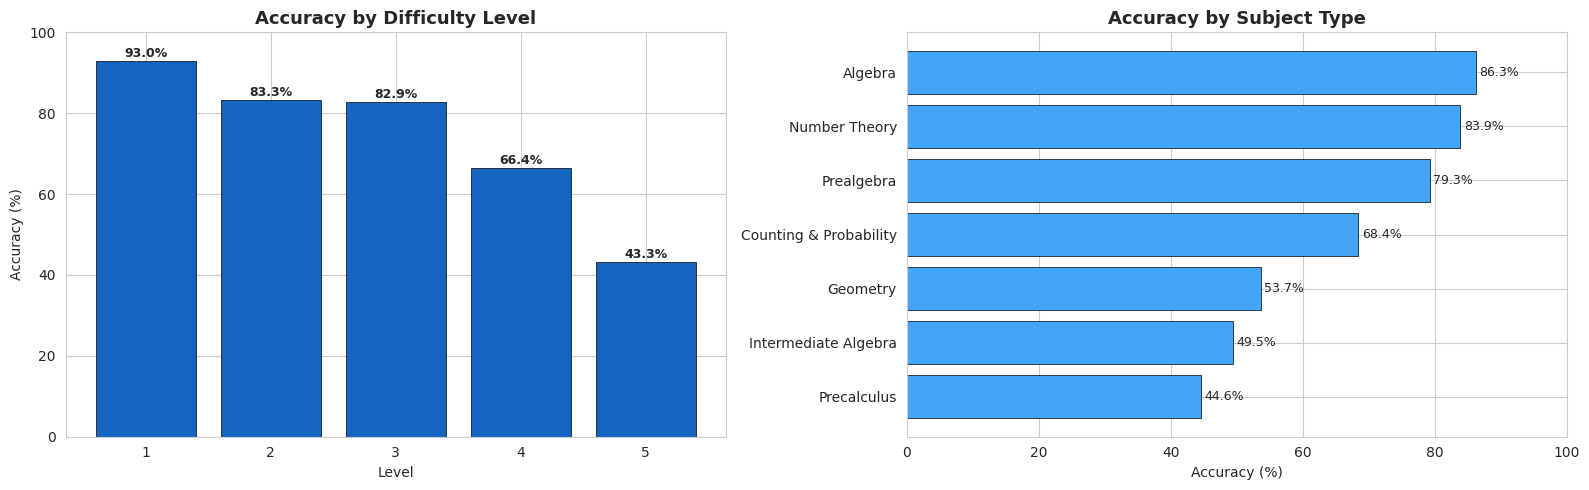

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

level_acc_sorted = level_acc.sort_index()
axes[0].bar(level_acc_sorted.index.astype(str), level_acc_sorted['Accuracy'],
            color='#1565C0', edgecolor='black', linewidth=0.5)
axes[0].set_title("Accuracy by Difficulty Level", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)
for i, (idx, row) in enumerate(level_acc_sorted.iterrows()):
    axes[0].text(i, row['Accuracy'] + 1, f"{row['Accuracy']:.1f}%",
                 ha='center', fontsize=9, fontweight='bold')

type_acc_sorted = type_acc.sort_values('Accuracy', ascending=True)
axes[1].barh(type_acc_sorted.index, type_acc_sorted['Accuracy'],
             color='#42A5F5', edgecolor='black', linewidth=0.5)
axes[1].set_title("Accuracy by Subject Type", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Accuracy (%)")
axes[1].set_xlim(0, 100)
for i, (idx, row) in enumerate(type_acc_sorted.iterrows()):
    axes[1].text(row['Accuracy'] + 0.5, i, f"{row['Accuracy']:.1f}%",
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/category_breakdown.png", dpi=300, bbox_inches='tight')
plt.show()


In [54]:
tradeoff = final_df[['Method', 'Accuracy', 'Token Savings (%)', 'Accuracy Drop']].copy()
tradeoff['Acc Drop per 10% Savings'] = (
    tradeoff['Accuracy Drop'] / (tradeoff['Token Savings (%)'] / 10)
).round(3)
tradeoff.loc[tradeoff['Token Savings (%)'] <= 0, 'Acc Drop per 10% Savings'] = 0.0

print("ACCURACY-EFFICIENCY TRADEOFF")
print("(How much accuracy is lost per 10% token savings)")
print("=" * 70)
print(tradeoff.to_string(index=False))


ACCURACY-EFFICIENCY TRADEOFF
(How much accuracy is lost per 10% token savings)
        Method  Accuracy  Token Savings (%)  Accuracy Drop  Acc Drop per 10% Savings
      Original      69.0               0.00            0.0                     0.000
     BeConcise      68.8              17.18            0.2                     0.116
   OnlyNumbers      53.4              38.76           15.6                     4.025
    AbbreWords      69.8              12.58           -0.8                    -0.636
Truncation_0.9      67.6               2.45            1.4                     5.714
Truncation_0.8      63.0               5.53            6.0                    10.850
Truncation_0.7      59.6               9.41            9.4                     9.989
Truncation_0.6      54.4              15.59           14.6                     9.365
Truncation_0.5      46.6              22.86           22.4                     9.799


/tmp/ipykernel_106/4192759582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=token_dist_df, x='Method', y='Tokens', palette='Blues', ax=ax)


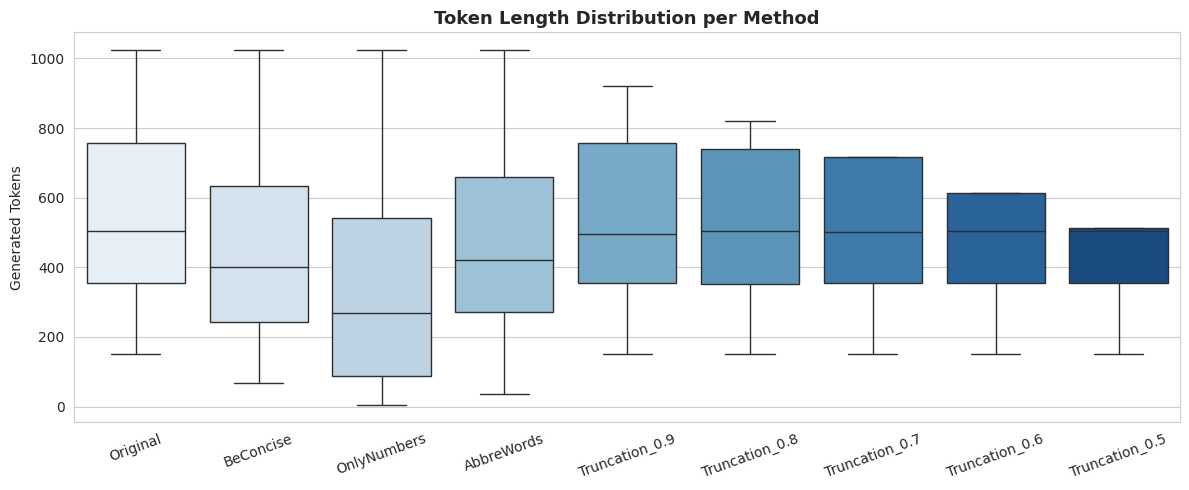

In [56]:
token_dist_data = []
for method, counts in all_token_counts_dict.items():
    for count in counts:
        token_dist_data.append({'Method': method, 'Tokens': count})

token_dist_df = pd.DataFrame(token_dist_data)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=token_dist_df, x='Method', y='Tokens', palette='Blues', ax=ax)
ax.set_title("Token Length Distribution per Method", fontsize=13, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Generated Tokens")
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig("/kaggle/working/token_distribution.png", dpi=300, bbox_inches='tight')
plt.show()